# Day 1: Linear Regression

从单变量到多变量，对比特征数量对线性回归效果的影响。

数据：Kaggle House Prices 数据集

In [7]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
# 加载数据
df = pd.read_csv("../data/train.csv")
y = np.log1p(df['SalePrice'].values)  # log1p 变换

In [9]:
# 定义标准化函数：fit 在训练集，transform 训练集和测试集
def standardize(train, test):
    mean = train.mean(axis=0)
    std = train.std(axis=0)
    return (train - mean) / std, (test - mean) / std

## 1. 单变量线性回归

只用 GrLivArea（居住面积）预测房价。

In [10]:
# 准备单变量数据
X_single = df[['GrLivArea']].values

# 80/20 拆分
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

# 标准化
X_s_train, X_s_test = standardize(X_s_train, X_s_test)

In [11]:
# 训练单变量模型
from models.linear_regression import LinearRegression

model_single = LinearRegression(lr=0.01, epochs=2000)
model_single.fit(X_s_train, y_s_train)

In [12]:
# 评估函数
def evaluate(model, X, y):
    y_pred = model.predict(X)
    mse = np.mean((y - y_pred) ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return rmse, r2

# 单变量评估
rmse_s_train, r2_s_train = evaluate(model_single, X_s_train, y_s_train)
rmse_s_test, r2_s_test = evaluate(model_single, X_s_test, y_s_test)
print(f"单变量 — Train R²: {r2_s_train:.2f}, Test R²: {r2_s_test:.2f}")

单变量 — Train R²: 0.47, Test R²: 0.54


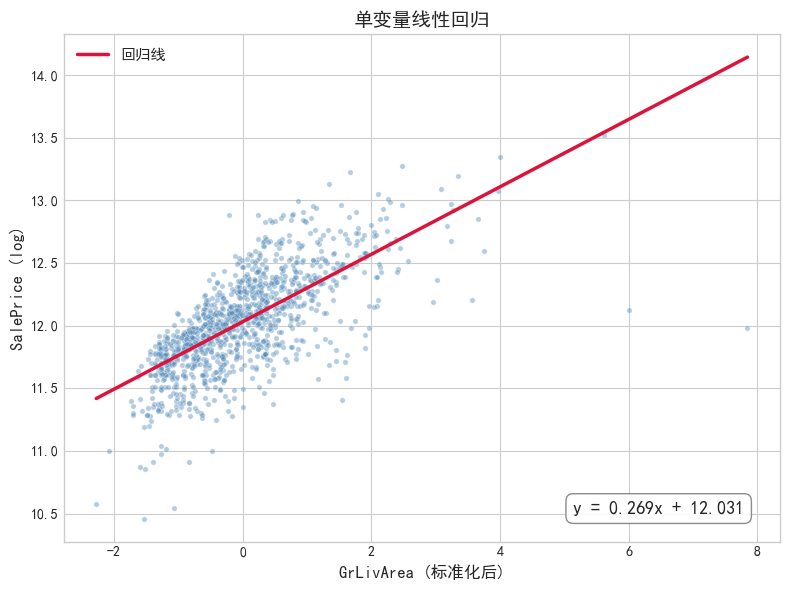

In [13]:
# 单变量：散点图 + 回归线
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 6))
y_pred_single = model_single.predict(X_s_train)
ax.scatter(X_s_train, y_s_train, alpha=0.4, s=15, color='steelblue', edgecolors='white', linewidth=0.5)
idx = X_s_train[:, 0].argsort()
ax.plot(X_s_train[idx], y_pred_single[idx], color='crimson', linewidth=2.5, label='回归线')

w = model_single.w[0]
b = model_single.b
equation = f'y = {w:.3f}x + {b:.3f}'
ax.text(0.95, 0.05, equation, transform=ax.transAxes, fontsize=13,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9))

ax.set_xlabel('GrLivArea (标准化后)', fontsize=12)
ax.set_ylabel('SalePrice (log)', fontsize=12)
ax.set_title('单变量线性回归', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 2. 多变量线性回归

加入更多数值型特征：

In [14]:
# 准备多变量数据
features = [
    'GrLivArea',
    'OverallQual',
    'TotalBsmtSF',
    'YearBuilt',
    'GarageCars',
    'FullBath'
]
X_multi = df[features].values

# 80/20 拆分（与单变量同一份随机种子）
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 标准化
X_m_train, X_m_test = standardize(X_m_train, X_m_test)

In [15]:
# 训练多变量模型
model_multi = LinearRegression(lr=0.01, epochs=2000)
model_multi.fit(X_m_train, y_m_train)

In [16]:
# 多变量评估
rmse_m_train, r2_m_train = evaluate(model_multi, X_m_train, y_m_train)
rmse_m_test, r2_m_test = evaluate(model_multi, X_m_test, y_m_test)
print(f"多变量 — Train R²: {r2_m_train:.2f}, Test R²: {r2_m_test:.2f}")

多变量 — Train R²: 0.80, Test R²: 0.84


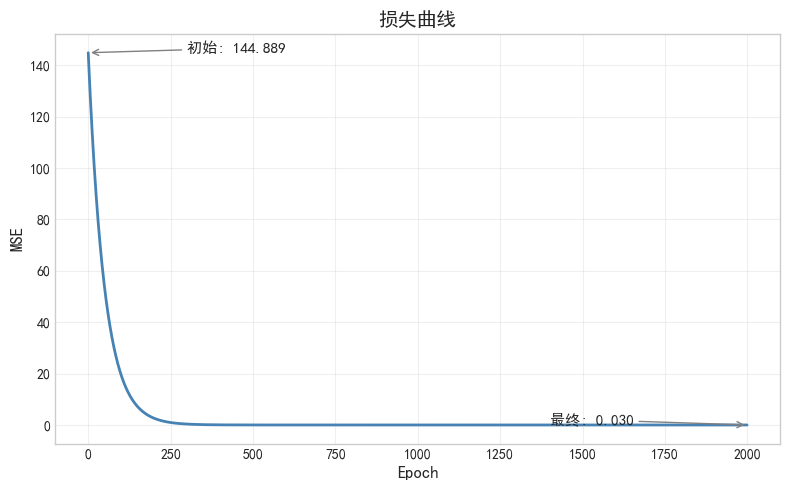

In [17]:
# 多变量：损失曲线
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(model_multi.losses, linewidth=2, color='steelblue')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('损失曲线', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

ax.annotate(f'初始: {model_multi.losses[0]:.3f}', xy=(0, model_multi.losses[0]),
            xytext=(300, model_multi.losses[0]-0.15),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11)
ax.annotate(f'最终: {model_multi.losses[-1]:.3f}', xy=(2000, model_multi.losses[-1]),
            xytext=(1400, model_multi.losses[-1]+0.1),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11)

plt.tight_layout()
plt.show()

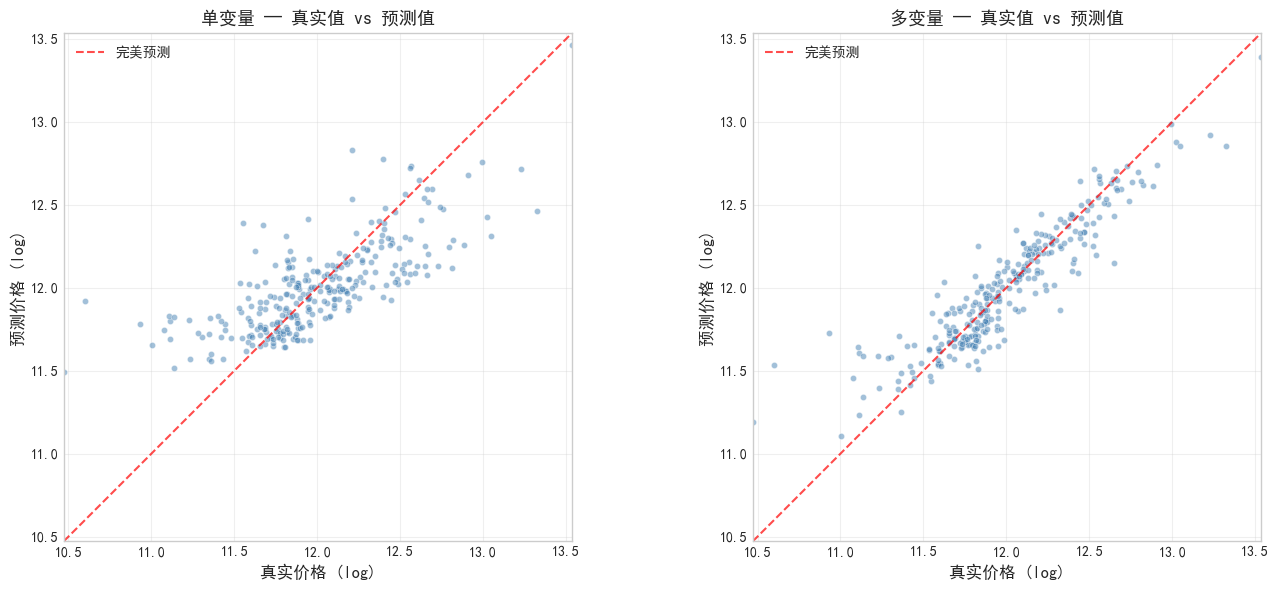

In [18]:
# 多变量：真实值 vs 预测值
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

y_pred_s_test = model_single.predict(X_s_test)
y_pred_m_test = model_multi.predict(X_m_test)

# 统一坐标范围
all_vals = np.concatenate([y_m_test, y_pred_s_test, y_pred_m_test])
min_v, max_v = all_vals.min(), all_vals.max()

for ax, y_pred, title in [
    (ax1, y_pred_s_test, '单变量'),
    (ax2, y_pred_m_test, '多变量')
]:
    ax.scatter(y_m_test, y_pred, alpha=0.5, s=20, color='steelblue', edgecolors='white', linewidth=0.5)
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, alpha=0.7, label='完美预测')
    ax.set_xlim(min_v, max_v)
    ax.set_ylim(min_v, max_v)
    ax.set_xlabel('真实价格 (log)', fontsize=12)
    ax.set_ylabel('预测价格 (log)', fontsize=12)
    ax.set_title(f'{title} — 真实值 vs 预测值', fontsize=13, fontweight='bold')
    ax.set_aspect('equal')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# 结果汇总
print("=" * 40)
print("结果对比")
print("=" * 40)
print(f"{'模型':<12} {'Train R²':<10} {'Test R²':<10}")
print(f"{'单变量':<12} {r2_s_train:<10.2f} {r2_s_test:<10.2f}")
print(f"{'多变量':<12} {r2_m_train:<10.2f} {r2_m_test:<10.2f}")

结果对比
模型           Train R²   Test R²   
单变量          0.47       0.54      
多变量          0.80       0.84      
